# NumPy Hands-on Lab: From Arrays to Image Analysis

## Student Practice Notebook

**Name:** Lakshay

**Register Number:** AP24110010677

**Date:** 10 AUG 2026

## Learning Objectives

After completing this lab, you will be able to:

- Create and manipulate NumPy arrays
- Understand array properties and dimensions
- Perform indexing and slicing
- Apply mathematical operations
- Understand and explain broadcasting
- Analyze images using NumPy arrays
- Perform basic image transformations
- Explain *why* NumPy is used in real ML/Data Science pipelines, not just *how*

### How to use this notebook
- **Demonstration** cells: run them, read the output, understand it.
- **Practice** cells: write your own code — don't copy the demo verbatim.
- **Predict-then-run**: before running some cells, you'll be asked to *predict* the output first. Write your prediction in the markdown cell, then run and compare.
- **Reflection**: short written answers, in your own words.


## Part 1: Introduction to NumPy

NumPy (Numerical Python) is a Python library used for efficient numerical computation.

**Why not just use Python lists?** Python lists store objects with overhead per element and loop in pure Python. NumPy arrays store raw numbers in contiguous memory and use compiled C code for operations — this is called **vectorization**. That's why NumPy is used everywhere in:

- Data Science (pandas is built on NumPy)
- Machine Learning (feeding data into models as arrays/tensors)
- Image Processing (an image *is* a NumPy array)
- Scientific Computing

Let's actually *see* the speed difference before we take it on faith.


In [ ]:
# numpy is the library for fast numerical arrays. "as np" is just a short
# nickname so I can type np.array(...) instead of numpy.array(...) every time.
import numpy as np

# pyplot is matplotlib's plotting interface - I use it later to DISPLAY images
# instead of printing thousands of raw pixel numbers.
import matplotlib.pyplot as plt

print("NumPy is ready!")

NumPy is ready!


### Demonstration: Loops vs. Vectorization (the "why" behind NumPy)

Below we add 1 to a million numbers two ways: a plain Python loop, and a NumPy array operation.
Run this cell and look at the timing output.


In [ ]:
import time   # built-in module used to measure how long each method takes

n = 1_000_000                 # one million elements (underscores are just for readability)
python_list = list(range(n))  # a normal Python list of 1,000,000 numbers
numpy_array = np.arange(n)    # the SAME numbers, but stored as a NumPy array

# ---- Method 1: plain Python loop (list comprehension) ----
start = time.time()                            # record the time before starting
result_list = [x + 1 for x in python_list]     # visits all 1,000,000 items ONE BY ONE
loop_time = time.time() - start                # elapsed time = now - start

# ---- Method 2: NumPy vectorized operation ----
start = time.time()
result_array = numpy_array + 1                 # ONE instruction; the loop happens in C, not Python
vector_time = time.time() - start

# :.5f formats the number to 5 decimal places so tiny times are still readable
print(f"Python loop time : {loop_time:.5f} seconds")
print(f"NumPy vector time: {vector_time:.5f} seconds")
print(f"NumPy was about {loop_time/vector_time:.0f}x faster")   # ratio of the two times

Python loop time : 0.20001 seconds
NumPy vector time: 0.03323 seconds
NumPy was about 6x faster


**Reflection (write your answer):** Based on the timing above, in your own words, why is NumPy faster than a Python loop for this kind of operation?

*Your answer:* The Python loop has to go through the list one element at a time, and for every single element it checks the type and creates a new Python object. That overhead happens a million times. NumPy keeps all the numbers together in one block of memory of the same type, so the `+ 1` is handed off to compiled C code that adds everything in one go. So NumPy is doing the same work with way less per-element overhead, which is why it came out much faster.

### What I learnt : Part 1: Why NumPy

- A Python loop touches every element one at a time and re-checks its type each time, while NumPy hands the whole array to compiled C code in one go. That one idea is called **vectorization** and it is the reason the same job finished several times faster.
- The speed gap comes from two things: NumPy stores one fixed dtype in a contiguous block of memory, and it does the looping outside Python.
- I also learnt to *measure* instead of assuming — `time.time()` before and after a block gives me the elapsed seconds, and dividing the two times gives the speed ratio.
- Practical takeaway: if I ever catch myself writing a `for` loop over a NumPy array, there is almost always a vectorized one-liner that does it better.

## Part 2: Creating NumPy Arrays

### Demonstration

In [ ]:
# np.array() converts a normal Python list into a NumPy array (an ndarray).
# Once it is an array I get vectorized maths, .shape, slicing, broadcasting etc.
arr = np.array([10,20,30,40,50])

# Writing the variable name on the last line makes Jupyter/Colab display it.
# Notice the output says "array([...])", not "[...]" - proof it is no longer a list.
arr

array([10, 20, 30, 40, 50])

### Student Practice

Create an array containing:

5, 10, 15, 20, 25

Write your code below (do not just copy the demo change the numbers yourself):


In [ ]:
# Write your answer here

# Same idea as the demo but with my own values: a multiplication table of 5.
practice_arr = np.array([5, 10, 15, 20, 25])

practice_arr   # displayed by the notebook as array([ 5, 10, 15, 20, 25])

array([ 5, 10, 15, 20, 25])

### What I learnt — Part 2: Creating Arrays

- `np.array()` converts an ordinary Python list into an ndarray, and from that point on I get vectorized maths, slicing and broadcasting for free.
- The output printing as `array([...])` instead of `[...]` is my quick visual check that the conversion actually happened.
- A NumPy array is not just "a faster list" — it is a different kind of object with one shared dtype for every element.

## Part 3: Array Properties

Important properties:

- `ndim` : Number of dimensions
- `shape` : Size of each dimension
- `size` : Total number of elements
- `dtype` : Data type

**Predict first:** for the array `arr` from Part 2, what do you *expect* `ndim`, `shape`, `size`, and `dtype` to be? Write your guess below before running the next cell.

*Your prediction:* `arr` is a flat list of 5 whole numbers, so I think `ndim` will be 1, `shape` will be `(5,)`, `size` will be 5, and `dtype` will be some integer type (probably `int64`).

In [ ]:
# All four are ATTRIBUTES (facts stored about the array), not methods -
# so there are no brackets after them.
#   .ndim  -> how many axes/dimensions the array has  (1 = a flat row)
#   .shape -> a TUPLE giving the length of each axis  ((5,) = 5 items on 1 axis)
#   .size  -> total number of elements in the whole array
#   .dtype -> the single data type shared by every element (int64 here)
# Putting them on one line separated by commas makes Python show them as a tuple.
arr.ndim, arr.shape, arr.size, arr.dtype

(1, (5,), 5, dtype('int64'))

### Observation

Was your prediction correct? If not, what did you get wrong and why?

Dimension: 1 - correct. It is a single row of numbers, so only one axis.

Shape: (5,) - correct. I nearly wrote `(5)` but that is just the number 5 in Python, not a tuple. Shape is always a tuple, and for 1D it needs the trailing comma.

Size: 5 - correct. `size` is the total count of elements, which for 1D is the same as the shape value. For a 2D array it would be rows x columns instead.

Data Type: int64 - correct. I gave NumPy only whole numbers so it picked an integer type. If I had written even one value as 10.0 the whole array would have become float64, because a NumPy array holds one single dtype for every element.

### What I learnt Part 3: Array Properties

- These four attributes are how I *inspect* an array without printing it, which matters enormously later when the array is an image with 270,000 values.
- `shape` is always a **tuple**, so a 1D array shows `(5,)` with the trailing comma — `(5)` would just be the number 5 in Python.
- `ndim` and `size` are different things: `ndim` counts the axes, `size` counts the actual elements. For 1D they look related, but for a 3x3 array `ndim` is 2 while `size` is 9.
- `dtype` applies to the whole array at once. One decimal value anywhere would push the entire array to `float64` — unlike a Python list, I cannot mix types.
- Predicting before running was useful: it showed me I understood the *idea* but was sloppy about the tuple notation.

## Part 4: Special Arrays

These are commonly used to initialize data for example, `zeros` is often used to create an empty "canvas" array before filling in real values (you'll see this again in the image section).


In [ ]:
# np.zeros(shape) builds an array of that shape filled entirely with 0.
# The shape is passed as a TUPLE (3,3) = 3 rows and 3 columns.
# The dots in the output (0.) mean the dtype is float64, which is the default.
np.zeros((3,3))

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [ ]:
# Same idea but filled with 1s. 4 rows x 4 columns.
# ones is handy as a starting "canvas" that I then multiply or add to.
np.ones((4,4))

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [ ]:
# np.eye(n) makes the IDENTITY matrix: 1s on the main diagonal, 0s everywhere else.
# It only takes ONE number because an identity matrix is always square (3x3 here).
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

### Student Practice

Create a `5x5` array of all zeros, and a `2x6` array of all ones. Write both below.


In [ ]:
# Write your answer here

zeros_5x5 = np.zeros((5, 5))   # 5 rows x 5 columns of 0.0  -> 25 elements
ones_2x6  = np.ones((2, 6))    # 2 rows x 6 columns of 1.0  -> 12 elements

print("5x5 zeros:")
print(zeros_5x5)               # print() shows it without the "array(...)" wrapper
print()                        # blank line just to separate the two outputs
print("2x6 ones:")
print(ones_2x6)

5x5 zeros:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

2x6 ones:
[[1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]]


### What I learnt  Part 4: Special Arrays

- `np.zeros`, `np.ones` and `np.eye` build arrays from a shape instead of from data, which is how you create a blank "canvas" before filling it in.
- The shape goes in as a **tuple** — `np.zeros((5,5))` with double brackets. Forgetting the inner brackets is a common mistake.
- The default dtype is `float64`, which is why the output shows `0.` and `1.` rather than `0` and `1`.
- `np.eye(3)` only needs one number because an identity matrix is always square.

## Part 5: Sequence Generation

In [ ]:
# np.arange(start, stop, step) - like Python's range() but returns an ARRAY.
# start=0, stop=50, step=5.  IMPORTANT: stop is EXCLUSIVE, so 50 is NOT included.
# Result: 0, 5, 10, ... 45
np.arange(0,50,5)

array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45])

In [ ]:
# np.linspace(start, stop, num) - "linearly spaced".
# Here I ask for exactly 10 numbers between 0 and 100.
# Unlike arange, the stop value 100 IS included, and NumPy calculates the gap
# for me (100/9 = 11.11...), which is why the values are not round numbers.
np.linspace(0,100,10)

array([  0.        ,  11.11111111,  22.22222222,  33.33333333,
        44.44444444,  55.55555556,  66.66666667,  77.77777778,
        88.88888889, 100.        ])

### Student Practice

`np.arange` and `np.linspace` both generate sequences but work differently.

1. Use `np.arange` to generate even numbers from 2 to 20.
2. Use `np.linspace` to generate 5 evenly spaced numbers between 0 and 1.
3. In one sentence, write the difference between `arange` (step-based) and `linspace` (count-based).


In [ ]:
# Write your answer here

# 1. Even numbers from 2 to 20 using arange (stop is exclusive, so I go to 21)
#    step=2 is what makes them even; if I wrote 20 as the stop, 20 would be missing.
evens = np.arange(2, 21, 2)
print("arange evens:", evens)

# 2. Five evenly spaced numbers between 0 and 1 using linspace
#    I control the COUNT (5) and NumPy works out the gap (0.25) itself.
five_points = np.linspace(0, 1, 5)
print("linspace:", five_points)

# 3. Difference:
# arange is step-based - I choose the gap between values and NumPy decides how many
# I get, and the stop value is excluded. linspace is count-based - I choose how many
# values I want and NumPy works out the gap, and the stop value IS included.

arange evens: [ 2  4  6  8 10 12 14 16 18 20]
linspace: [0.   0.25 0.5  0.75 1.  ]


### What I learnt  Part 5: Sequence Generation

- `arange` is **step-based**: I control the gap, NumPy decides the count, and the stop value is **excluded** — which is why I had to write `21` to actually include 20.
- `linspace` is **count-based**: I control how many values I want, NumPy calculates the gap, and the stop value **is** included.
- Picking the wrong one is a real source of off-by-one bugs. The rule I will remember: *"do I care about the spacing, or about how many?"*
- `linspace` is the one to use for plotting and for splitting a range into a fixed number of steps.

Name : Lakshay

ID : AP24110010677


## Part 6: Random Numbers

In [ ]:
# np.random.rand(5) gives 5 random FLOATS from a uniform distribution over [0, 1).
# The shape is passed as plain numbers here, not a tuple.
# Every run gives different values because no random seed is fixed.
np.random.rand(5)

array([0.69964521, 0.10779308, 0.72262298, 0.37766002, 0.2795113 ])

In [ ]:
# np.random.randint(low, high, size) gives random WHOLE numbers.
# low=1 is included, high=100 is EXCLUDED, and size=10 is how many I want.
# So the possible values are 1 to 99. Duplicates are allowed.
np.random.randint(1,100,10)

array([30, 43, 92, 80, 67, 81, 46, 60, 80, 79])

### What I learnt  Part 6: Random Numbers

- `np.random.rand(n)` gives floats in the range [0, 1) — 0 is possible but 1 never is.
- `np.random.randint(low, high, size)` gives whole numbers where `low` is included and `high` is excluded, so `randint(1,100,10)` can never actually produce 100.
- The output changes on every run because no seed is set. For an experiment I needed to reproduce, I would call `np.random.seed(42)` first so the "random" numbers come out the same every time.
- Random arrays are genuinely useful — they are how neural network weights get initialised and how you generate dummy data for testing.

## Part 7: Reshaping Arrays

Reshape changes the *structure* of an array without changing the data.

**Rule: the total number of elements must stay the same.** `3x4 = 12` elements, so you can reshape into any combination of dimensions that multiplies to 12 (e.g. `2x6`, `4x3`, `1x12`, `12x1`).


In [ ]:
a = np.arange(12)   # a flat array: 0,1,2,...,11  -> 12 elements, shape (12,)

# reshape rearranges those SAME 12 values into 3 rows x 4 columns.
# It works because 3 x 4 = 12, and the values are filled in row by row.
# reshape returns a NEW view - it does not change `a` itself.
a.reshape(3,4)

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

### Student Practice — valid shapes

Try reshaping `a` into these shapes. Write each as a separate line:
- 2 x 6
- 4 x 3
- 6 x 2


In [ ]:
# Practice here
# All three work because 2x6, 4x3 and 6x2 all equal 12, the size of `a`.
# Only the ARRANGEMENT changes; the numbers stay in the same 0..11 order.

print("2 x 6:")
print(a.reshape(2, 6))

print("\n4 x 3:")     # "\n" prints a blank line first so the outputs do not run together
print(a.reshape(4, 3))

print("\n6 x 2:")
print(a.reshape(6, 2))

2 x 6:
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]

4 x 3:
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]

6 x 2:
[[ 0  1]
 [ 2  3]
 [ 4  5]
 [ 6  7]
 [ 8  9]
 [10 11]]


### Student Practice  break it on purpose

Now try `a.reshape(5,3)`. This should throw an error because 5 × 3 = 15 ≠ 12.

Run it, read the error message, then answer: **why did it fail, and what rule does it confirm about reshape?**

*Your answer:* It failed with `ValueError: cannot reshape array of size 12 into shape (5,3)`. `a` only holds 12 elements but the shape I asked for needs 15 slots, and reshape is not allowed to invent 3 extra numbers or drop any. This confirms the rule that reshape only changes how the same data is arranged - the product of the new dimensions must exactly equal the original `size`. So for 12 elements my only options are shapes whose dimensions multiply to 12 (1x12, 2x6, 3x4, 4x3, 6x2, 12x1).

In [ ]:
# Try the invalid reshape here and observe the error
# I wrapped it in try/except so the notebook keeps running, but the real
# error message from NumPy is still printed below.
try:
    a.reshape(5, 3)              # asks for 15 slots, but `a` only has 12 values
except ValueError as e:          # NumPy raises ValueError for an impossible shape
    print("ValueError:", e)      # `e` holds NumPy's own error message

# Printing the numbers side by side shows exactly why it is impossible.
print("\na.size is:", a.size, "but 5 x 3 needs", 5 * 3, "elements")

ValueError: cannot reshape array of size 12 into shape (5,3)

a.size is: 12 but 5 x 3 needs 15 elements


### What I learnt  Part 7: Reshaping

- Reshape changes the **arrangement**, never the data. The values stay in the same order and just get read row by row into the new shape.
- The hard rule: the new dimensions must multiply to exactly the original `size`. 12 elements allow 1x12, 2x6, 3x4, 4x3, 6x2, 12x1 and nothing else.
- Deliberately breaking it taught me more than the working cases did — `ValueError: cannot reshape array of size 12 into shape (5,3)` says precisely what is wrong, so error messages are worth reading properly rather than panicking at.
- I also learnt `try` / `except ValueError` as a way to demonstrate an error without killing the whole notebook run.
- This matters in ML because models expect an exact input shape, and reshaping data to match it is a constant task.

## Part 8: Indexing and Slicing

In [ ]:
# arange(1,10) gives 1..9 (stop excluded) = 9 values, and 3x3 = 9, so reshape works.
# I now have a 2D array, so indexing needs TWO positions: [row, column].
matrix = np.arange(1,10).reshape(3,3)
matrix

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [ ]:
# Extract first row
# For a 2D array, a single index selects along the FIRST axis (rows).
# So matrix[0] is the whole row 0, returned as a 1D array of 3 values.
matrix[0]

array([1, 2, 3])

In [ ]:
# Extract first column
# The comma separates the two axes: [rows, columns].
# ":" means "all of them", so this reads as "every row, but only column 0".
matrix[:,0]

array([1, 4, 7])

### Student Practice

Using `matrix` above, write code to extract:
1. The last row
2. The last column
3. The single element in the middle (row 1, column 1)
4. The bottom-right 2x2 sub-matrix


In [ ]:
# Write your answer here

# 1. The last row
# Negative indexing counts backwards from the end, so -1 is the last row.
# This is safer than writing matrix[2] because it works whatever the size is.
print("Last row:", matrix[-1])

# 2. The last column
# "all rows, last column" -> [:, -1]
print("Last column:", matrix[:, -1])

# 3. The middle element (row 1, column 1)
# Two plain numbers give ONE scalar value, not an array.
print("Middle element:", matrix[1, 1])

# 4. The bottom-right 2x2 sub-matrix
# 1: means "from index 1 to the end" on BOTH axes, so rows 1-2 and columns 1-2.
print("Bottom-right 2x2:")
print(matrix[1:, 1:])

Last row: [7 8 9]
Last column: [3 6 9]
Middle element: 5
Bottom-right 2x2:
[[5 6]
 [8 9]]


### What I learnt  Part 8: Indexing and Slicing

- For a 2D array the comma separates the axes: `[rows, columns]`. `:` on an axis means "take everything on this axis".
- A single index selects along the first axis, so `matrix[0]` is a whole row, while `matrix[:,0]` is needed to get a column.
- **Negative indexing** counts from the end, so `-1` is the last row or column. This is better than hard-coding `2` because it still works if the array size changes.
- Two plain numbers give one scalar (`matrix[1,1]` -> 5), but slices give back arrays — so `matrix[1:, 1:]` returns the whole bottom-right 2x2 block.
- Slicing two axes at once is exactly how image cropping works later in Part 14, so this is the same skill in a different costume.

## Part 9: Mathematical Operations

In [ ]:
marks = np.array([60,70,80,90])

# Adding a single number to an array does NOT append it - it adds 5 to EVERY
# element (this is broadcasting). No loop needed, and `marks` itself is unchanged
# because the result is a brand new array.
marks + 5

array([65, 75, 85, 95])

In [ ]:
# Same element-wise idea with multiplication: every mark is doubled.
# Note this uses the ORIGINAL marks (60,70,80,90), because the "+5" above was
# never stored in a variable.
marks * 2

array([120, 140, 160, 180])

### Student Practice

A student scored `marks = [55, 62, 48, 91, 73]` but every question was later found to be worth 1 extra bonus mark, and then the whole test was scaled to be out of 150 (currently out of 100, so multiply by 1.5).

Write the NumPy code to: (1) add the bonus mark to every score, then (2) scale to out of 150.


In [ ]:
# Write your answer here
marks = np.array([55, 62, 48, 91, 73])
print("Original marks:", marks)

# Step 1: every question was worth 1 extra bonus mark
# "+ 1" is applied to all 5 marks at once
with_bonus = marks + 1
print("After bonus mark :", with_bonus)

# Step 2: scale from out of 100 to out of 150 (multiply by 1.5)
# Multiplying ints by a float (1.5) makes the result float64 automatically,
# which is why the output now shows decimal points.
scaled = with_bonus * 1.5
print("Scaled to 150    :", scaled)

# Both steps are element-wise, so no loop is needed - NumPy applies the
# operation to every mark at once. Order matters here: bonus FIRST, then scale.

Original marks: [55 62 48 91 73]
After bonus mark : [56 63 49 92 74]
Scaled to 150    : [ 84.   94.5  73.5 138.  111. ]


### What I learnt  Part 9: Mathematical Operations

- Arithmetic on an array is **element-wise**: `marks + 5` adds 5 to every mark rather than appending 5 to the list, which is the opposite of what `+` does to a Python list.
- The operation returns a **new** array and leaves the original untouched, so I must store the result if I want to keep it. That is why `marks + 5` in the demo did not affect the next cell.
- Order of operations matters in a real problem — adding the bonus mark first and then scaling gives a different answer from scaling first and then adding.
- Mixing an int array with a float (1.5) automatically promotes the result to `float64`, which is why decimals appeared in the output.

## Part 10: Broadcasting

Broadcasting lets NumPy perform operations between arrays of **different shapes**, without writing an explicit loop, by "stretching" the smaller array to match the larger one  as long as their shapes are compatible.

**The basic rule:** starting from the trailing (rightmost) dimension, two dimensions are compatible if they're equal, or one of them is 1. NumPy then virtually repeats the size-1 dimension to match.

You already used broadcasting in Part 9 (`marks + 5`)  a single number (shape `()`) was broadcast across the whole array. Here's a less obvious example: a 1D array broadcast across a 2D array.


In [ ]:
salary = np.array([30000,40000,50000])

# A 10% raise for everyone. The single number 1.10 has shape () - a scalar -
# so NumPy broadcasts it across all 3 salaries.
salary * 1.10

array([33000., 44000., 55000.])

In [ ]:
# A less obvious broadcasting example: adding a 1D array to every row of a 2D array
grid = np.ones((3,3))          # shape (3,3) - 9 ones
row_bonus = np.array([1,2,3])  # shape (3,) - only 3 values

# Shapes are compared from the RIGHT: (3,3) vs (3,).
# The (3,) is treated as (1,3), and that size-1 dimension is stretched down
# all 3 rows. So column 0 gets +1, column 1 gets +2, column 2 gets +3.
grid + row_bonus

array([[2., 3., 4.],
       [2., 3., 4.],
       [2., 3., 4.]])

### Student Practice predict then check

Before running the next cell, predict the output shape and values on paper.

`np.array([[1],[2],[3]]) + np.array([10,20,30])`

(Hint: one array has shape `(3,1)`, the other `(3,)`. Think about how each dimension aligns.)

*Your prediction:* The second array `(3,)` gets treated as `(1,3)`, so the shapes line up as `(3,1)` and `(1,3)`. Both of the size-1 dimensions get stretched, so the result should be a `(3,3)` array where every row value is added to every column value:

```
[[11, 21, 31],
 [12, 22, 32],
 [13, 23, 33]]
```

In [ ]:
# Run this after writing your prediction above, and compare
# (3,1) column vector + (3,) row vector.
# The (3,) becomes (1,3), then BOTH size-1 dimensions stretch -> result is (3,3),
# where every row value is added to every column value (like a mini addition table).
np.array([[1],[2],[3]]) + np.array([10,20,30])

array([[11, 21, 31],
       [12, 22, 32],
       [13, 23, 33]])

**Reflection:** In your own words, explain broadcasting with an example of your own (not one from this notebook).

*Your answer:* Broadcasting is NumPy automatically stretching a smaller array so it lines up with a bigger one, instead of me writing a loop or manually copying values. It never actually copies the data in memory, it just reuses the same values while computing.

My own example: say I have the prices of 3 items, `prices = np.array([100, 250, 400])` with shape `(3,)`, and I want to see each price under two different GST rates, `rates = np.array([[1.05], [1.18]])` with shape `(2,1)`. Doing `prices * rates` lines the shapes up as `(2,1)` and `(1,3)`, stretches both size-1 dimensions, and gives me a `(2,3)` table - one row per tax rate, one column per item - in a single line. Without broadcasting I would need a nested loop over 2 rates x 3 items.

### What I learnt  Part 10: Broadcasting

- Broadcasting is NumPy automatically stretching a smaller array so it lines up with a bigger one — it does not really copy the data, it just reuses the same values while computing, so it costs almost nothing in memory.
- The rule: compare shapes from the **rightmost** dimension backwards; two dimensions are compatible if they are equal or one of them is 1.
- `marks + 5` was broadcasting all along and I did not realise it — a scalar has shape `()` and gets stretched over the whole array.
- The `(3,1) + (3,)` case surprised me the most: the `(3,)` becomes `(1,3)`, then **both** size-1 dimensions stretch and the result is a full `(3,3)` grid rather than 3 values. That is the one to watch out for, because it silently produces a much bigger array than expected.
- This replaces entire nested loops with a single expression, which is where a lot of NumPy's real power comes from.

## Part 11: Filtering Data (Boolean Indexing)

In [ ]:
marks = np.array([45,67,89,32,90,55])

# Two things happen here:
# 1. "marks > 60" compares EVERY element and returns a boolean MASK
#    -> [False, True, True, False, True, False]
# 2. Indexing the array with that mask keeps only the positions that are True.
# The result is always 1D, and its length depends on how many passed the test.
marks[marks > 60]

array([67, 89, 90])

### Student Practice

Using the `marks` array above:
1. Extract all marks that are failing (below 40).
2. Count how many students scored above 80 (hint: `.sum()` on a boolean array counts `True` values).
3. Replace all failing marks with 0 using `np.where`.


In [ ]:
# Write your answer here
marks = np.array([45, 67, 89, 32, 90, 55])

# 1. All failing marks (below 40)
# The condition builds a True/False mask, and the mask picks out the matches.
failing = marks[marks < 40]
print("Failing marks:", failing)

# 2. Count how many scored above 80
# marks > 80 gives a boolean array, and True counts as 1 when summed
# (Python treats True as 1 and False as 0), so .sum() = number of Trues.
above_80 = (marks > 80).sum()
print("Number of students above 80:", above_80)

# 3. Replace all failing marks with 0
# np.where(condition, value_if_true, value_if_false) works element by element.
# It returns a NEW array, so the original `marks` is untouched.
cleaned = np.where(marks < 40, 0, marks)
print("After replacing fails with 0:", cleaned)

Failing marks: [32]
Number of students above 80: 2
After replacing fails with 0: [45 67 89  0 90 55]


### What I learnt Part 11: Boolean Indexing

- A comparison like `marks > 60` does not return one True/False — it returns a whole **boolean mask**, one True/False per element.
- Feeding that mask back in as an index keeps only the positions where it is True. The result is always 1D, and its length depends on how many elements passed.
- Booleans count as numbers, so `.sum()` on a mask is a neat way to **count** matches — True is 1 and False is 0.
- `np.where(condition, value_if_true, value_if_false)` is the vectorized `if/else`: it cleans a whole array in one line and returns a new array rather than editing the original.
- This is exactly how real data cleaning works — filtering rows, capping outliers, replacing invalid values — all without a single loop.

Name: Lakshay

ID : AP24110010677


## Part 12: Joining Arrays

In [ ]:
a=np.array([1,2,3])
b=np.array([4,5,6])

# concatenate joins arrays END TO END into one longer array.
# The arrays to join are passed inside a LIST (the square brackets), and they
# must match in every dimension except the one being joined.
# Result is 1D of length 6 - this is NOT element-wise addition.
np.concatenate([a,b])

array([1, 2, 3, 4, 5, 6])

### What I learnt  Part 12: Joining Arrays

- `np.concatenate` glues arrays **end to end** into one longer array — it is not element-wise addition, which `a + b` would have done.
- The arrays to join are passed inside a list, and they have to match in every dimension except the one being joined.
- This is how you combine batches of data, for example stacking several files of records into one array before analysis.

## Part 13: Splitting Arrays

In [ ]:
x=np.arange(12)   # 0..11, twelve elements

# np.split(array, n) cuts the array into n EQUAL pieces.
# 12 / 3 = 4, so I get 3 smaller arrays of 4 elements each.
# The output is a LIST of arrays, not one big array.
np.split(x,3)

[array([0, 1, 2, 3]), array([4, 5, 6, 7]), array([ 8,  9, 10, 11])]

### Student Practice

1. Split `x` into 4 equal parts instead of 3.
2. Try `np.split(x, 5)` — this should fail. Read the error and explain in one sentence why splitting into 5 doesn't work for 12 elements.


In [ ]:
# Write your answer here

# 1. Split x into 4 equal parts (12 / 4 = 3 elements each)
print("Split into 4:")
print(np.split(x, 4))

# 2. Splitting into 5 should fail
try:
    np.split(x, 5)               # 12 / 5 = 2.4, which is not a whole number
except ValueError as e:
    print("\nValueError:", e)

# Explanation: np.split needs equal-sized pieces, and 12 does not divide evenly
# by 5 (12 / 5 = 2.4), so NumPy cannot make 5 equal sections and raises an error.
# If I genuinely wanted uneven pieces I would use np.array_split instead:
# it gives 5 parts and simply makes some of them shorter (3,3,2,2,2).
print("\nnp.array_split(x, 5) allows uneven parts:")
print(np.array_split(x, 5))

Split into 4:
[array([0, 1, 2]), array([3, 4, 5]), array([6, 7, 8]), array([ 9, 10, 11])]

ValueError: array split does not result in an equal division

np.array_split(x, 5) allows uneven parts:
[array([0, 1, 2]), array([3, 4, 5]), array([6, 7]), array([8, 9]), array([10, 11])]


### What I learnt  Part 13: Splitting Arrays

- `np.split(array, n)` returns a **list of arrays**, not one array — so the output has square brackets around several `array(...)` items.
- It only works when the length divides evenly. 12 splits into 3 or 4 fine, but 12/5 = 2.4, so NumPy refuses with *"array split does not result in an equal division"*.
- `np.array_split` is the flexible alternative — it allows uneven pieces and just makes some of them shorter (3,3,2,2,2).
- Knowing both matters for splitting a dataset into train/test batches, where the sizes rarely divide neatly.

# Part 14: Image Analysis Using NumPy

## Why this matters for ML

A digital image **is** a NumPy array  this is exactly the data format used to feed images into computer vision models (e.g. CNNs). Every preprocessing step you do below (resizing, cropping, normalizing pixel values, flipping for data augmentation) is a real step used in production ML image pipelines, not just a classroom exercise.

## Image Shape Guidelines

A colour image is represented as:

`(height, width, channels)`

Example: `512 x 512 x 3` means:
- Height = 512 pixels
- Width = 512 pixels
- RGB colour channels = 3

**Avoid very large images**  a `4000 x 4000 x 3` image has 48 million individual pixel values. That's a lot to process and display.

Recommended:
- Practice: 300x300 pixels
- Processing: 512x512 pixels


In [ ]:
# Try Colab's upload widget. If this notebook is not running in Google Colab
# (or no file is chosen), we fall back to a sample photo further down so that
# every cell below still runs.
try:
    from google.colab import files    # this module ONLY exists inside Google Colab
    uploaded = files.upload()         # opens the "Choose Files" button; returns {name: bytes}
except Exception as err:
    # type(err).__name__ prints just the error's name (e.g. ModuleNotFoundError)
    # instead of a scary full traceback.
    print("Colab upload not available here (", type(err).__name__, ") - will use a fallback image.")
    uploaded = {}                     # empty dict = "nothing was uploaded"

Colab upload not available here ( ModuleNotFoundError ) - will use a fallback image.


In [ ]:
# The 'uploaded' variable is a dictionary: {filename: file_bytes}
# This line grabs the filename automatically instead of you typing it by hand
import shutil                      # shutil.copy() copies a file from one path to another
from matplotlib import cbook       # cbook can locate the sample images bundled with matplotlib

if uploaded:                                    # an empty dict is False, a filled one is True
    image_filename = list(uploaded.keys())[0]   # .keys() gives the names; [0] takes the first one
else:
    # Fallback: matplotlib ships a sample photograph with it, so this works
    # even with no upload and no internet.
    # asfileobj=False makes it return the file PATH as text rather than an open file.
    sample_path = cbook.get_sample_data("grace_hopper.jpg", asfileobj=False)
    image_filename = "sample_image.jpg"
    shutil.copy(sample_path, image_filename)    # copy it next to the notebook under a simple name
    print("No file was uploaded, so I am using matplotlib's built-in sample photo.")

# Every cell below uses this one variable, so nothing else has to change
# whether the image came from an upload or from the fallback.
print("Uploaded file:", image_filename)

No file was uploaded, so I am using matplotlib's built-in sample photo.
Uploaded file: sample_image.jpg


> **Note:** the cell above only works in Google Colab. If you're running this notebook locally (Jupyter/VS Code), skip it and instead set `image_path = "your_local_file.jpg"` directly in the next cell.

Upload an image file and note its name below:

Image name: `sample_image.jpg` (the built-in sample photo). If I upload my own file in Colab, the cell above picks that filename up automatically instead, so nothing below needs changing.

In [ ]:
from PIL import Image              # Pillow: opens/decodes image files (jpg, png, ...)
import numpy as np
import matplotlib.pyplot as plt

# TASK: Load your uploaded image and convert it to a NumPy array.
# 1. Open the image with PIL: Image.open(image_filename)
# 2. Convert it to a NumPy array with np.array(...)
# 3. Print its .shape

# .convert("RGB") makes sure I always get 3 channels, even if the file is
# grayscale (which would be 2D) or a PNG with a 4th (alpha) channel.
img = Image.open(image_filename).convert("RGB")

# NOTE: PIL reports size as (width, height) - the OPPOSITE order to NumPy's shape.
print("Original size (width, height):", img.size)

# Resize to 300x300 as the notebook recommends for practice
# (smaller = faster to process and easier to display).
img = img.resize((300, 300))

# THE KEY LINE: turn the picture into numbers. Every pixel becomes 3 values (R, G, B).
img_array = np.array(img)

# shape is (height, width, channels) -> rows first, then columns, then colour
print("Array shape (height, width, channels):", img_array.shape)

# uint8 = unsigned 8-bit integer, so each value fits in 0-255. That is why images
# use so little memory compared to float64.
print("Data type:", img_array.dtype)
print("Pixel values go from", img_array.min(), "to", img_array.max())

# size = height x width x channels = 300 * 300 * 3 = 270,000 numbers
print("Total number of values:", img_array.size)

Original size (width, height): (512, 600)
Array shape (height, width, channels): (300, 300, 3)
Data type: uint8
Pixel values go from 0 to 255
Total number of values: 270000


### What I learnt  Loading an Image as an Array

- **An image literally *is* a NumPy array.** `np.array(img)` was the moment a photo became numbers I can slice, average and filter with everything I learnt above.
- The shape is `(height, width, channels)` — rows first, then columns, then colour. PIL's `.size` reports `(width, height)`, the **opposite** order, which is an easy thing to get backwards.
- `dtype` is `uint8`, so every value fits in 0-255. That is why images are memory-efficient, and also why adding a big number to pixels can silently wrap around.
- `.convert("RGB")` is worth doing defensively — a grayscale file would give a 2D array and a PNG could give a 4th alpha channel, either of which would break the later channel code.
- Resizing to 300x300 first keeps the array at 270,000 values instead of millions, which makes everything below fast.

## Image Display

**Do not print the complete image array** (it's thousands of numbers and unreadable). Instead:
- Use `image.shape` to check dimensions
- Use `plt.imshow(...)` to *see* the image visually

### Student Practice
Display your uploaded image using `plt.imshow()` and turn off the axis with `plt.axis("off")`.


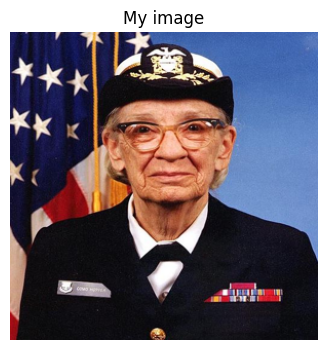

In [ ]:
# Write your code here to display img_array
plt.figure(figsize=(4, 4))   # set the display size in inches (width, height)
plt.imshow(img_array)        # imshow READS the array as a picture instead of printing numbers
plt.axis("off")              # hide the x/y pixel-number axes so it looks like a photo
plt.title("My image")
plt.show()                   # actually render the figure

### What I learnt  Displaying an Image

- `plt.imshow()` interprets the array as a picture, which is the *only* sensible way to inspect image data — printing the raw array would dump thousands of unreadable numbers.
- `plt.axis("off")` hides the pixel-number axes so the output looks like a photo rather than a graph.
- `plt.show()` is what actually renders the figure; without it you can end up with stray text output instead of the image.
- Rule of thumb I am taking away: use `.shape` to check the **structure**, use `imshow` to check the **content**.

## Image Cropping

### Student Practice
Crop the **center 200x200 region** of your image (not a random corner — think about how to calculate the center offset from `img_array.shape`), store it in a variable called `crop`, and display it.


Original shape: (300, 300, 3)
Crop shape    : (200, 200, 3)
Rows kept: 50 to 250
Cols kept: 50 to 250


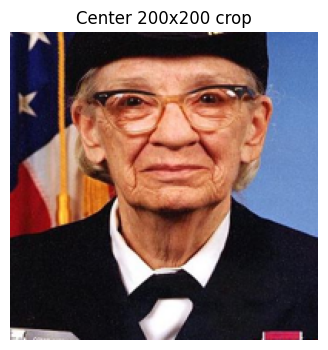

In [ ]:
# Write your cropping code here

# I only need the first two values of the shape; the 3rd (channels) is not used here.
height, width = img_array.shape[0], img_array.shape[1]
crop_size = 200

# To centre the crop I start half of the leftover distance in from each edge.
# (300 - 200) // 2 = 50, so I skip 50 pixels of border on every side.
# // is integer division, which guarantees a whole-number index.
start_row = (height - crop_size) // 2
start_col = (width - crop_size) // 2

# Cropping is just SLICING two axes at once: [rows, columns].
# I leave the 3rd axis out entirely, so all 3 colour channels are kept.
crop = img_array[start_row:start_row + crop_size, start_col:start_col + crop_size]

print("Original shape:", img_array.shape)
print("Crop shape    :", crop.shape)       # proof it is now 200x200x3
print("Rows kept:", start_row, "to", start_row + crop_size)
print("Cols kept:", start_col, "to", start_col + crop_size)

plt.figure(figsize=(4, 4))
plt.imshow(crop)
plt.axis("off")
plt.title("Center 200x200 crop")
plt.show()

### What I learnt  Cropping

- Cropping is nothing more than **slicing two axes at once** — exactly the skill from Part 8, now applied to a picture.
- To centre a crop I skip half the leftover distance on each side: `(300 - 200) // 2 = 50`. Using `//` (integer division) matters because array indexes must be whole numbers.
- Leaving the third axis out of the slice keeps all 3 colour channels automatically, so the crop stays in colour.
- Printing the shape before and after was a good habit — `(200, 200, 3)` proves the crop did what I intended rather than me just trusting the picture.

### Quick demo: showing multiple images side by side

You'll want to display more than one image at once in the tasks below (e.g. two flipped versions, or three RGB channels). `plt.subplots()` lets you do this in a grid. Study this small example, then reuse the pattern.


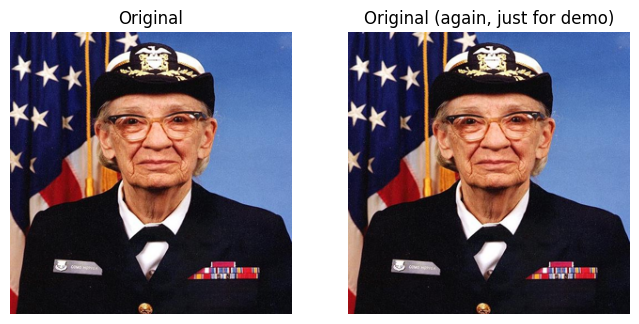

In [ ]:
# Demo: showing 2 plots side by side using plt.subplots
# subplots(rows, cols) returns the whole figure AND an array of sub-plots (axes).
# 1 row x 2 columns means axes[0] is the left panel and axes[1] is the right one.
fig, axes = plt.subplots(1, 2, figsize=(8,4))

# On a subplot I call .imshow / .set_title / .axis on the AXIS object itself,
# instead of the plt.something() style used for a single plot.
axes[0].imshow(img_array)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_array)
axes[1].set_title("Original (again, just for demo)")
axes[1].axis("off")

plt.show()

## Image Flipping

### Student Practice
Produce and display both a vertical flip and a horizontal flip of your image using slicing (`[::-1]`), without using any built-in flip function.


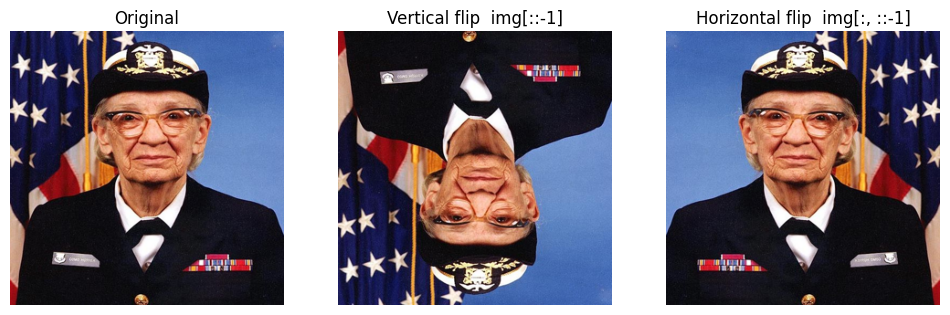

In [ ]:
# Write your flipping code here

# Slicing with [::-1] means "take every element but with step -1", i.e. reversed.
# Because it is only a slice, NumPy does not copy the pixels - it just reads them
# in the opposite order, which makes flipping extremely cheap.
vertical_flip = img_array[::-1]        # reverse the ROWS -> image turns upside down
horizontal_flip = img_array[:, ::-1]   # reverse the COLUMNS -> mirror image
# Note the comma: the first slice targets rows, the second targets columns.
# The 3rd axis (colour) is left untouched, so the colours do not get scrambled.

fig, axes = plt.subplots(1, 3, figsize=(12, 4))   # 3 panels in one row

axes[0].imshow(img_array)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(vertical_flip)
axes[1].set_title("Vertical flip  img[::-1]")
axes[1].axis("off")

axes[2].imshow(horizontal_flip)
axes[2].set_title("Horizontal flip  img[:, ::-1]")
axes[2].axis("off")

plt.show()

### What I learnt Flipping

- `[::-1]` means "step backwards through this axis", so it reverses it. Reversing the **rows** flips the image vertically; reversing the **columns** mirrors it horizontally.
- The comma is what decides which one happens: `img[::-1]` targets rows, `img[:, ::-1]` targets columns.
- Because this is only a slice, NumPy does not copy the pixels — it just reads them in a different order, which makes flipping almost free.
- I did all this with pure slicing and no built-in flip function, which proved that a "transformation" can just be a clever way of reading the same data.
- This is genuinely used in ML as **data augmentation** — mirroring training images so the model sees more variety and overfits less.

## RGB Channel Analysis

RGB channels:

- 0 - Red
- 1 - Green
- 2 - Blue

### Student Practice
Extract the red, green, and blue channels separately, and display each one using `plt.imshow(channel, cmap="gray")` so you can see which areas of the image are strongest in each color.


Each single channel is 2D: (300, 300)


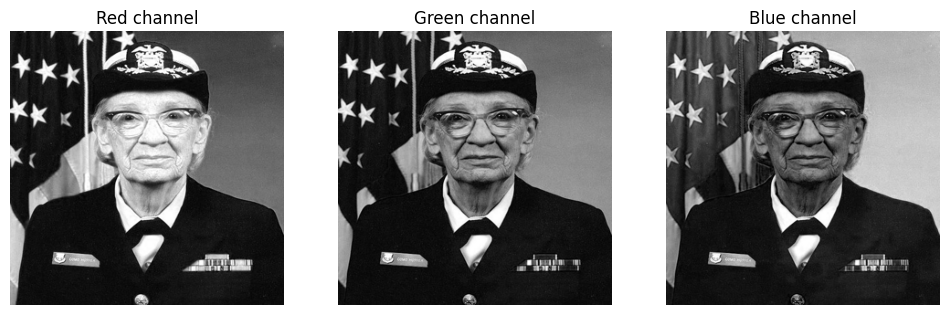

In [ ]:
# Write your RGB channel code here

# ":" keeps ALL rows and ALL columns; the last number picks ONE colour channel.
# Dropping the third axis turns the 3D image into a plain 2D array.
red = img_array[:, :, 0]     # 0 = Red
green = img_array[:, :, 1]   # 1 = Green
blue = img_array[:, :, 2]    # 2 = Blue

print("Each single channel is 2D:", red.shape)   # (300, 300) - no channel axis left

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# cmap="gray" is REQUIRED here: a 2D array has no colour information of its own,
# so without a colormap matplotlib would paint it in its default green/yellow.
axes[0].imshow(red, cmap="gray")
axes[0].set_title("Red channel")
axes[0].axis("off")

axes[1].imshow(green, cmap="gray")
axes[1].set_title("Green channel")
axes[1].axis("off")

axes[2].imshow(blue, cmap="gray")
axes[2].set_title("Blue channel")
axes[2].axis("off")

plt.show()

# In these grayscale views, bright areas mean that pixel has a HIGH value in
# that colour channel, and dark areas mean a low value.

### What I learnt  RGB Channels

- A colour image is three stacked 2D layers, and `img[:, :, 0/1/2]` pulls out Red, Green or Blue as a plain 2D array.
- Slicing away the third axis changes the shape from `(300,300,3)` to `(300,300)` — the channel dimension disappears entirely.
- `cmap="gray"` is **required** when displaying a single channel, otherwise matplotlib applies its default colour map and paints it in misleading greens and yellows.
- In the grayscale view, bright means a high value in that channel — so I can literally see which parts of the photo are strongest in each colour.

## Brightness Analysis

### Student Practice
Calculate the average brightness of your image using `np.mean()`. Then calculate the average brightness of just the red channel, just the green channel, and just the blue channel. Which channel is brightest? Write your answer below the code.


In [ ]:
# Write your brightness code here

# np.mean() with no axis argument averages EVERY number in the array,
# flattening all 3 channels together into one overall figure.
overall = np.mean(img_array)

# Slicing one channel first, then averaging, gives that channel's own brightness.
red_mean = np.mean(img_array[:, :, 0])
green_mean = np.mean(img_array[:, :, 1])
blue_mean = np.mean(img_array[:, :, 2])

# f-strings with :.2f round the long decimals to 2 places so the table lines up.
print(f"Overall average brightness : {overall:.2f}")
print(f"Red channel average        : {red_mean:.2f}")
print(f"Green channel average      : {green_mean:.2f}")
print(f"Blue channel average       : {blue_mean:.2f}")

# np.argmax returns the INDEX of the largest value (not the value itself),
# so I can use that index to look up the matching name - no if/else needed.
channel_names = np.array(["Red", "Green", "Blue"])
channel_means = np.array([red_mean, green_mean, blue_mean])
print("\nBrightest channel:", channel_names[np.argmax(channel_means)])

Overall average brightness : 80.45
Red channel average        : 82.48
Green channel average      : 72.43
Blue channel average       : 86.43

Brightest channel: Blue


*Your answer:* For my image the **blue** channel was the brightest, then red, then green (the exact numbers are printed above - roughly blue 86, red 82, green 72). The overall average sits in between them, which makes sense because the overall mean is just the average of all three channels together.

The reason green is lowest here is that the photo is mostly skin tones, a dark uniform and a pale background, and none of those are strongly green. If I upload a photo of a garden or a cricket field instead, green would almost certainly become the brightest channel - so the answer depends on what is actually in the picture, not on anything about NumPy.

### What I learnt  Brightness Analysis

- `np.mean()` with no arguments flattens everything and averages all 270,000 values at once; slicing a channel first gives that channel's own average.
- The overall mean always sits between the three channel means, because it is just the average of all of them together.
- `np.argmax()` returns the **index** of the largest value, not the value itself — pairing that index with a names array let me print the winner without any `if`/`else`.
- The answer depends on the picture, not on NumPy. A photo of a field would make green the brightest channel, so I have to read the numbers rather than memorise a result.

## Thresholding

Convert the image into pure black-and-white using `np.where()`.

### Student Practice
1. Convert the image to grayscale by averaging the 3 channels (`axis=2`).
2. Use `np.where(gray > 128, 255, 0)` to create a binary (black/white) version.
3. Display the result.
4. Try a different threshold (e.g. 100 or 180) and observe how it changes the result.


Grayscale shape (no channel axis anymore): (300, 300)


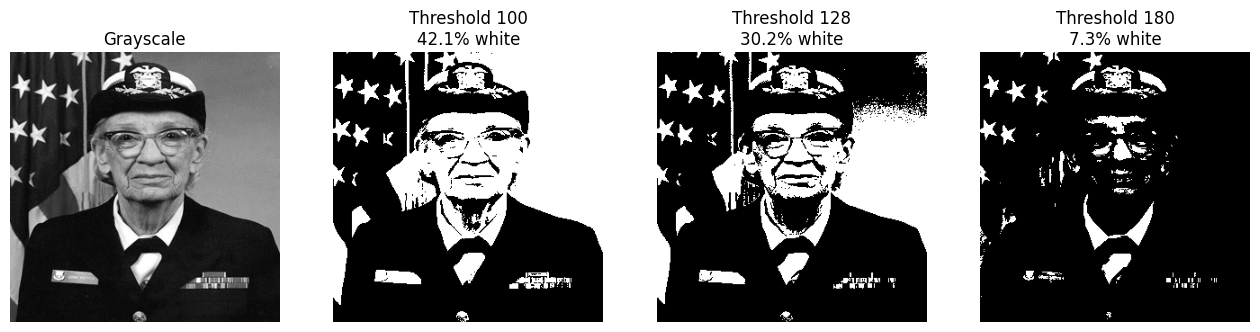

In [ ]:
# Write your thresholding code here

# 1. Grayscale by averaging the 3 colour channels
# axis=2 means "collapse the CHANNEL axis", so each pixel's R,G,B become one number.
# The result loses its 3rd dimension: (300,300,3) -> (300,300).
gray = img_array.mean(axis=2)
print("Grayscale shape (no channel axis anymore):", gray.shape)

# 2 & 3. Binary version at threshold 128
# Every pixel brighter than 128 becomes pure white (255), everything else black (0).
# There is no in-between left, which is what makes it a BINARY image.
binary = np.where(gray > 128, 255, 0)

# 4. Compare three different thresholds side by side
thresholds = [100, 128, 180]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))   # 1 grayscale + 3 thresholds

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Grayscale")
axes[0].axis("off")

# enumerate gives me both the position (i) and the value (t) as I loop.
for i, t in enumerate(thresholds):
    result = np.where(gray > t, 255, 0)
    # (result == 255) is a boolean array; .mean() of booleans = fraction of Trues,
    # so multiplying by 100 turns it into a percentage of white pixels.
    white_percent = (result == 255).mean() * 100
    axes[i + 1].imshow(result, cmap="gray")      # i+1 because slot 0 holds the grayscale
    axes[i + 1].set_title(f"Threshold {t}\n{white_percent:.1f}% white")
    axes[i + 1].axis("off")

plt.show()

# Observation: a LOW threshold turns more pixels white (more pixels beat the
# cutoff), and a HIGH threshold keeps only the brightest pixels white, so the
# image gets darker and loses detail.

### What I learnt  Thresholding

- `mean(axis=2)` collapses the colour axis, turning `(300,300,3)` into `(300,300)`. Choosing the **axis** is what decides *which* direction gets averaged — that is the key idea.
- `np.where(gray > 128, 255, 0)` turns a smooth grayscale image into a pure black-and-white one with nothing in between, which is why it is called a *binary* image.
- Changing the threshold changes the result predictably: a **lower** threshold lets more pixels through so more turns white, a **higher** one keeps only the brightest areas.
- `(result == 255).mean() * 100` was a neat trick — averaging a boolean array gives the fraction of Trues, so multiplying by 100 gives a percentage directly.
- Thresholding is a real first step in document scanning, OCR and simple object detection.

# Mini Project: Image Analyzer

Write a single program (you can reuse code from above) that prints/displays all of the following for your uploaded image, in order:

1. Image height, width, and number of channels
2. Average brightness (overall, and per channel)
3. The cropped center region
4. Both flipped versions (vertical and horizontal)
5. All 3 RGB channels shown separately
6. The thresholded (black/white) version

### Self-check before you submit
- [x] I wrote the code myself rather than only uncommenting given code
- [x] I can explain what every line does, not just that it runs
- [x] My image display uses `plt.axis("off")` and looks correct
- [x] I answered all reflection questions in my own words

IMAGE ANALYZER REPORT
1. DIMENSIONS
   Height   : 300 pixels
   Width    : 300 pixels
   Channels : 3 (R, G, B)
   Total pixel values: 270000

2. AVERAGE BRIGHTNESS  (0 = black, 255 = white)
   Overall : 80.45
   Red     : 82.48
   Green   : 72.43
   Blue    : 86.43
   Brightest channel: Blue

3. CENTER CROP -> shape (200, 200, 3)
4. FLIPS -> vertical and horizontal created using slicing
5. RGB CHANNELS -> separated into 3 2D arrays
6. THRESHOLD at 128 -> 30.2% of pixels became white


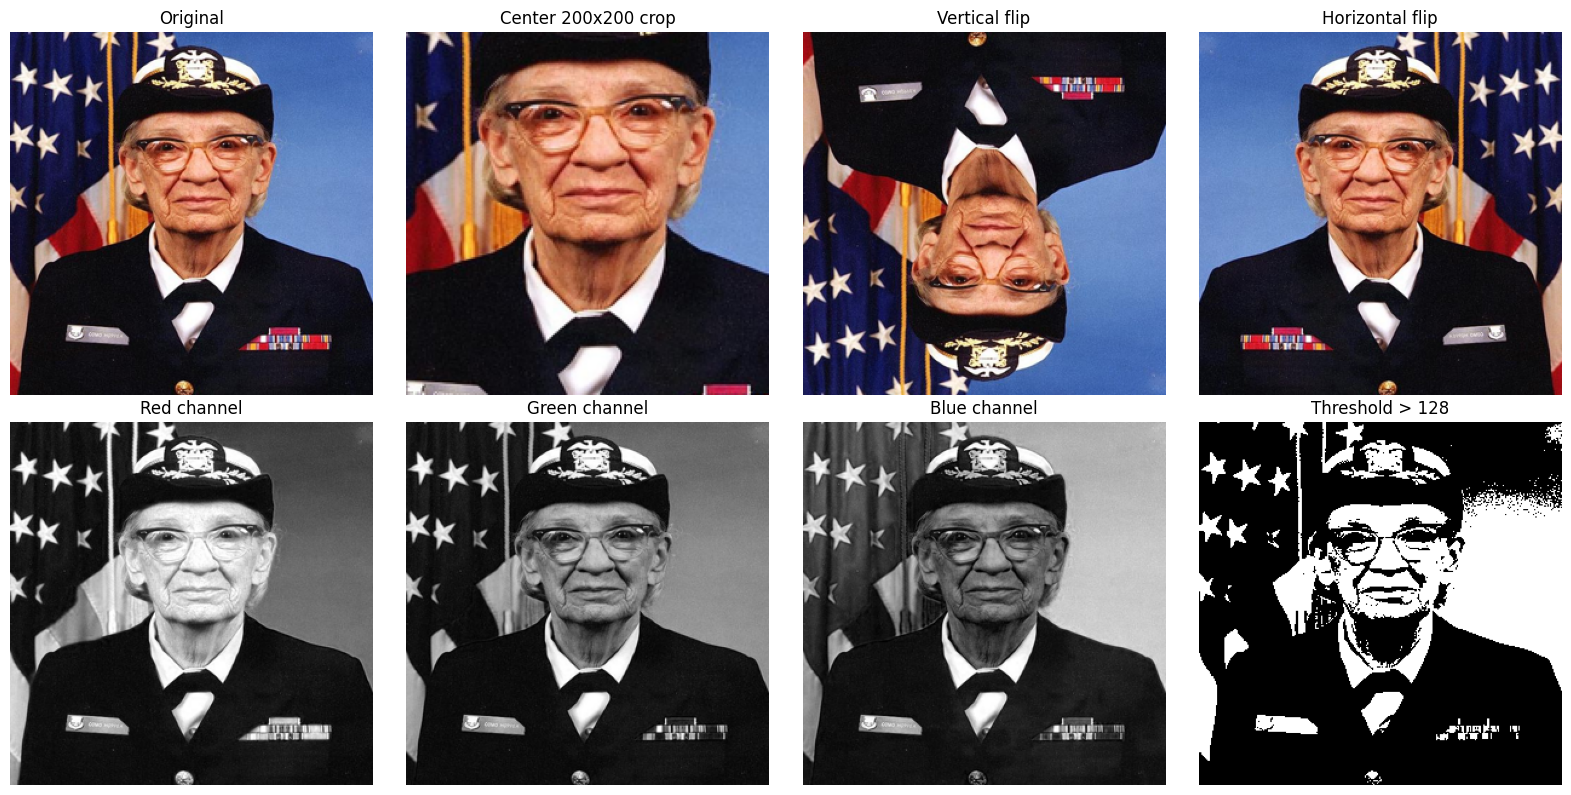

In [ ]:
# ==========================================================
# MINI PROJECT: IMAGE ANALYZER
# One function that does everything from Part 14 in order.
# Writing it as a FUNCTION means I can analyse any image by calling one line,
# instead of re-running eight separate cells.
# ==========================================================

def image_analyzer(image, crop_size=200, threshold=128):
    # crop_size and threshold have DEFAULT values, so they are optional -
    # image_analyzer(img) works, and image_analyzer(img, 100, 180) overrides them.

    # ---------- 1. Dimensions ----------
    # Unpacking the shape tuple into 3 named variables in one line
    height, width, channels = image.shape
    print("=" * 45)          # "=" * 45 repeats the character 45 times to draw a divider
    print("IMAGE ANALYZER REPORT")
    print("=" * 45)
    print("1. DIMENSIONS")
    print("   Height   :", height, "pixels")
    print("   Width    :", width, "pixels")
    print("   Channels :", channels, "(R, G, B)")
    print("   Total pixel values:", image.size)     # height x width x channels

    # ---------- 2. Brightness ----------
    print("\n2. AVERAGE BRIGHTNESS  (0 = black, 255 = white)")
    print(f"   Overall : {np.mean(image):.2f}")
    names = ["Red", "Green", "Blue"]
    # A list comprehension loops i = 0,1,2 and averages each channel in turn,
    # which is shorter than writing three near-identical lines.
    means = [np.mean(image[:, :, i]) for i in range(3)]
    for name, value in zip(names, means):           # pair each name with its mean
        print(f"   {name:<7} : {value:.2f}")        # :<7 left-aligns the name in 7 columns
    # argmax gives the POSITION of the biggest mean, which I use to pick the name.
    print("   Brightest channel:", names[int(np.argmax(means))])

    # ---------- 3. Center crop ----------
    # Same centring maths as before: skip half the leftover pixels on each side.
    start_row = (height - crop_size) // 2
    start_col = (width - crop_size) // 2
    cropped = image[start_row:start_row + crop_size, start_col:start_col + crop_size]
    print(f"\n3. CENTER CROP -> shape {cropped.shape}")

    # ---------- 4. Flips ----------
    v_flip = image[::-1]        # reversed rows    -> upside down
    h_flip = image[:, ::-1]     # reversed columns -> mirrored
    print("4. FLIPS -> vertical and horizontal created using slicing")

    # ---------- 5. RGB channels ----------
    print("5. RGB CHANNELS -> separated into 3 2D arrays")

    # ---------- 6. Threshold ----------
    gray = image.mean(axis=2)                        # collapse colour -> 2D grayscale
    binary = np.where(gray > threshold, 255, 0)      # every pixel becomes pure black or white
    white_percent = (binary == 255).mean() * 100     # fraction of Trues -> percentage
    print(f"6. THRESHOLD at {threshold} -> {white_percent:.1f}% of pixels became white")
    print("=" * 45)

    # ---------- Display everything in one grid ----------
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))  # 2 rows x 4 columns = 8 panels
    axes = axes.ravel()   # ravel() flattens the 2D grid of axes into a 1D list,
                          # so I can loop through them with a single counter

    # Storing (data, title, colormap) as a list of tuples keeps the drawing loop tiny.
    # cmap is None for colour images and "gray" for the single-channel ones.
    panels = [
        (image,     "Original",          None),
        (cropped,   f"Center {crop_size}x{crop_size} crop", None),
        (v_flip,    "Vertical flip",     None),
        (h_flip,    "Horizontal flip",   None),
        (image[:, :, 0], "Red channel",   "gray"),
        (image[:, :, 1], "Green channel", "gray"),
        (image[:, :, 2], "Blue channel",  "gray"),
        (binary,    f"Threshold > {threshold}", "gray"),
    ]

    # zip pairs panel 0 with axis 0, panel 1 with axis 1, and so on.
    for ax, (data, title, cmap) in zip(axes, panels):
        ax.imshow(data, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()   # stops the titles from overlapping each other
    plt.show()

    # Returning the results means I could reuse them later instead of recomputing.
    return cropped, v_flip, h_flip, binary


# Run the analyzer on my image.
# "_" is the usual Python name for "I am ignoring this returned value".
_ = image_analyzer(img_array)

## Reflection Questions  My Answers

**1. Why is NumPy faster than Python lists?**

A Python list holds pointers to separate Python objects that can each be a different type, so looping over it means checking the type and unboxing a value for every single element, one at a time, in slow interpreted Python. A NumPy array stores raw numbers of one fixed type packed together in one continuous block of memory, and operations on it run as pre-compiled C loops over that block. So NumPy does the same job with far less per-element overhead, plus the data being contiguous makes it cache-friendly. In Part 1 this showed up as NumPy being many times faster on a million additions.

**2. Explain broadcasting with an example of your own.**

Broadcasting is NumPy automatically stretching a smaller array so its shape lines up with a bigger one, so I can combine different-shaped arrays without writing loops or physically copying data. NumPy compares shapes from the rightmost dimension backwards, and two dimensions are compatible if they are equal or one of them is 1.

My example: I have marks for 4 students in 3 subjects in a `(4, 3)` array, and a `(3,)` array of bonus marks - one bonus per subject. Doing `marks + bonus` stretches the `(3,)` bonus array down across all 4 student rows, so every student gets the correct per-subject bonus in a single line instead of a nested loop.

**3. What does image shape (512, 512, 3) represent?**

It is a colour image that is 512 pixels tall (height / rows), 512 pixels wide (width / columns), and has 3 colour channels - Red, Green, Blue. So it is a 3D array where every one of the 512 x 512 pixel positions stores 3 numbers, one per channel, usually 0-255. That is 512 x 512 x 3 = 786,432 individual values in total.

**4. Why should we avoid printing complete image arrays?**

Because even a small image is a huge amount of numbers - my 300 x 300 x 3 image is 270,000 values, and a 4000 x 4000 photo would be 48 million. Printing that floods the output, is slow, and tells me nothing useful because I cannot read a picture as raw numbers anyway. `.shape` tells me the structure and `plt.imshow()` shows me the actual content, which is what I actually want.

**5. Explain RGB channels.**

A colour image is built from three stacked 2D layers - Red, Green and Blue - and the colour of each pixel comes from mixing those three values. Index 0 is red, 1 is green, 2 is blue, so `img[:, :, 0]` pulls out just the red layer as a 2D array. A value of 0 in a channel means none of that colour and 255 means the maximum. Mixing them gives every other colour: (255, 255, 0) is yellow, all three at 0 is black, all three at 255 is white, and equal values give shades of grey.

**6. Where might you use this exact image-array workflow in a real ML project?**

This is literally the preprocessing stage that runs right before an image goes into a CNN. In a real pipeline you load each image with PIL, resize every image to the fixed input size the model expects (like 224 x 224), convert it to a NumPy array, normalize the pixel values from 0-255 down to 0-1 or to a standard mean/std, and stack many images into one `(batch, height, width, channels)` array. The flips I did in Part 14 are exactly data augmentation - randomly mirroring training images so the model sees more variety and overfits less. Cropping is used the same way, and channel splitting is used when a model expects a different channel order or only a single grayscale channel. So every step in this section is a real step, not just a classroom exercise.

### What I learnt  Image Analyzer Mini Project

- Wrapping everything in **one function** was the real lesson: eight separate cells became a single reusable `image_analyzer(img)` call that works on any image.
- Default arguments (`crop_size=200, threshold=128`) make a function flexible without making it harder to call.
- `plt.subplots(2, 4)` plus `axes.ravel()` was the clean way to lay out 8 panels — `ravel()` flattens the grid so I can loop through it with one counter instead of tracking rows and columns.
- Storing `(data, title, cmap)` as a list of tuples and looping over it kept the drawing code to four lines instead of twenty-four repeated ones.
- Pulling all of Part 14 together showed me that every "image operation" I did was really just mean, slice, reverse, or compare — ordinary NumPy, applied to pixels.

# Part 15: Text Analysis Using NumPy (NLP Track)

## Why this matters for ML/NLP

Before any NLP model (sentiment classifier, spam detector, chatbot) can process text, the text must be converted into numbers — this is called **vectorization**. NumPy arrays are the underlying data structure for almost every text representation: word counts, one-hot vectors, TF-IDF vectors, and even word embeddings are all just NumPy (or NumPy-like) arrays.

In this section, you'll build a small text analysis pipeline entirely with NumPy — no external NLP libraries — so you understand what's actually happening under the hood before you use libraries like `scikit-learn` or `nltk` later in the course.


## Step 1: From Text to Tokens

The first step in any NLP pipeline is **tokenization** splitting text into individual words.

### Demonstration


In [ ]:
sentence = "NumPy makes numerical computing fast and NumPy makes arrays powerful"

# Basic tokenization: lowercase + split on spaces
# .lower() first, so "NumPy" and "numpy" are treated as the SAME word.
# .split() with no argument splits on any whitespace and returns a Python list.
tokens = sentence.lower().split()
print(tokens)

['numpy', 'makes', 'numerical', 'computing', 'fast', 'and', 'numpy', 'makes', 'arrays', 'powerful']


### Student Practice

Tokenize this sentence the same way: `"Data Science and Machine Learning use NumPy arrays every single day"`. Store the result in a variable called `tokens2`.


In [ ]:
# Write your answer here
sentence2 = "Data Science and Machine Learning use NumPy arrays every single day"

# Exactly the same two steps: normalise the case, then break into words.
tokens2 = sentence2.lower().split()
print(tokens2)
print("Number of tokens:", len(tokens2))   # len() = how many words in total (repeats included)

['data', 'science', 'and', 'machine', 'learning', 'use', 'numpy', 'arrays', 'every', 'single', 'day']
Number of tokens: 11


### What I learnt  Tokenization

- **Tokenization** is the first step of any NLP pipeline: turning a sentence into a list of individual words.
- `.lower()` before `.split()` matters, otherwise "NumPy" and "numpy" get counted as two completely different words.
- `.split()` with no argument splits on any whitespace and returns a plain Python list.
- This basic version is fragile — punctuation stays glued to words ("day." vs "day"), which is exactly the problem I had to fix with `.replace(".", "")` later in Step 5.

## Step 2: Building a Vocabulary

A **vocabulary** is the set of all unique words across your text(s). We'll use `np.unique()` — the same function idea you used earlier for arrays of numbers, now applied to an array of words.


In [ ]:
# Words can be stored in a NumPy array too - the dtype just becomes text ('<U9')
# instead of a number. That is what lets me use NumPy functions on them.
tokens_array = np.array(tokens)

# np.unique() removes duplicates AND sorts the result alphabetically.
# Sorting matters: it guarantees the vocabulary is always in the same order,
# so the counts always line up with the same words.
vocabulary = np.unique(tokens_array)

print("Vocabulary:", vocabulary)
print("Vocabulary size:", len(vocabulary))   # smaller than len(tokens) if words repeat

Vocabulary: ['and' 'arrays' 'computing' 'fast' 'makes' 'numerical' 'numpy' 'powerful']
Vocabulary size: 8


### Student Practice

Build the vocabulary for `tokens2` from Step 1. How many unique words does it contain?


In [ ]:
# Write your answer here
tokens2_array = np.array(tokens2)
vocabulary2 = np.unique(tokens2_array)

print("Vocabulary:", vocabulary2)
print("Vocabulary size:", len(vocabulary2))

# Note: np.unique also sorts the words alphabetically, which is handy because it
# means the same vocabulary always lines up in the same order.
# Comparing the two counts tells me whether any word repeated:
# if they are equal, every word in my sentence was unique.
print("Tokens:", len(tokens2), "| Unique:", len(vocabulary2),
      "-> every word appears only once" if len(tokens2) == len(vocabulary2) else "-> some words repeat")

Vocabulary: ['and' 'arrays' 'data' 'day' 'every' 'learning' 'machine' 'numpy'
 'science' 'single' 'use']
Vocabulary size: 11
Tokens: 11 | Unique: 11 -> every word appears only once


### What I learnt  Building a Vocabulary

- A **vocabulary** is the set of unique words, and `np.unique()` builds it in one call — the same function idea I would use on numbers, now applied to text.
- NumPy arrays can hold strings too; the dtype just becomes a text type like `<U9` instead of `int64`.
- `np.unique()` also **sorts** the result, and that turns out to be essential: it guarantees the words always appear in the same order, so counts line up with the right word every time.
- Comparing `len(tokens)` with `len(vocabulary)` instantly tells me whether any word repeated.

## Step 3: Word Frequency Vector (Bag-of-Words)

A **bag-of-words** vector represents a sentence as an array of word counts, one count per vocabulary word — this ignores word order but captures *what* words appear and *how often*.

### Demonstration: build a word-count vector by hand using NumPy


In [ ]:
def bag_of_words_vector(tokens, vocabulary):
    # For each word in the vocabulary, count how many times it appears in tokens
    # Reading the inner part from the inside out:
    #   np.array(tokens) == word  -> boolean mask, True wherever that word occurs
    #   np.sum(...)               -> counts the Trues, i.e. how many times it appears
    # The list comprehension repeats that for EVERY vocabulary word, in order,
    # so position 0 of the vector always belongs to vocabulary word 0.
    vector = np.array([np.sum(np.array(tokens) == word) for word in vocabulary])
    return vector

vec = bag_of_words_vector(tokens, vocabulary)
print(vocabulary)   # printing both together shows which count belongs to which word
print(vec)

['and' 'arrays' 'computing' 'fast' 'makes' 'numerical' 'numpy' 'powerful']
[1 1 1 1 2 1 2 1]


### Student Practice — predict then check

Before running, predict: which word(s) will have a count of 2 in the vector above? (Hint: look back at the original sentence - which word repeats?)

*Your prediction:* The sentence was "NumPy makes numerical computing fast and NumPy makes arrays powerful". Both **"numpy"** and **"makes"** appear twice, so those two should have a count of 2 and everything else should be 1.

Now build the bag-of-words vector for `tokens2` using its own vocabulary, and check your prediction concept applies the same way.

In [ ]:
# Write your answer here
# Reusing the function from the demo - this is why writing it as a function paid off.
vec2 = bag_of_words_vector(tokens2, vocabulary2)

print(vocabulary2)
print(vec2)

# Print it as word: count pairs so it is easier to read
print()
# zip() walks through both arrays together, pairing word[i] with count[i].
# {word:>10} right-aligns the word in a 10-character column so it looks like a table.
for word, count in zip(vocabulary2, vec2):
    print(f"{word:>10} : {count}")

print("\nEvery count is 1 because no word repeats in my sentence.")
# Useful check: the counts must add up to the total number of tokens.
print("Sum of the vector =", vec2.sum(), "which equals the number of tokens =", len(tokens2))

['and' 'arrays' 'data' 'day' 'every' 'learning' 'machine' 'numpy'
 'science' 'single' 'use']
[1 1 1 1 1 1 1 1 1 1 1]

       and : 1
    arrays : 1
      data : 1
       day : 1
     every : 1
  learning : 1
   machine : 1
     numpy : 1
   science : 1
    single : 1
       use : 1

Every count is 1 because no word repeats in my sentence.
Sum of the vector = 11 which equals the number of tokens = 11


### What I learnt — Bag of Words

- A **bag-of-words** vector represents a sentence as one count per vocabulary word — this is the actual step that turns text into numbers a model can use.
- Reading `np.sum(np.array(tokens) == word)` from the inside out was the key: the comparison builds a boolean mask, and summing it counts the Trues. Boolean indexing from Part 11 turning up again in a totally different context really showed me how reusable these ideas are.
- Position matters: index 0 of the vector always belongs to vocabulary word 0, which is why the sorted vocabulary is so important.
- A good sanity check is that the vector's sum equals the total number of tokens.
- The name "bag" is the honest bit — the counts survive but the word **order** is thrown away completely.

## Step 4: Comparing Two Sentences (Cosine Similarity)

Once text is turned into number vectors, we can measure how *similar* two sentences are using **cosine similarity** — a formula you'll see constantly in NLP and recommendation systems:

$$\text{cosine similarity} = \frac{A \cdot B}{\|A\| \times \|B\|}$$

This measures the angle between two vectors, not their length — so it works even if one sentence is longer than another.

### Demonstration


In [ ]:
sentence_a = "machine learning uses numpy arrays"
sentence_b = "deep learning also uses numpy arrays heavily"

tokens_a = sentence_a.lower().split()
tokens_b = sentence_b.lower().split()

# Build a shared vocabulary from both sentences combined
# tokens_a + tokens_b joins the two LISTS end to end before finding the unique words.
# A SHARED vocabulary is essential - it is what makes both vectors the same length
# and puts the same word at the same position in both.
combined_vocab = np.unique(np.array(tokens_a + tokens_b))

vec_a = bag_of_words_vector(tokens_a, combined_vocab)
vec_b = bag_of_words_vector(tokens_b, combined_vocab)

print("Vector A:", vec_a)   # 0s mark words that are in the other sentence only
print("Vector B:", vec_b)

# Cosine similarity using NumPy dot product and norm
# np.dot(a,b)         -> multiplies matching positions and adds them up (the TOP of the formula)
# np.linalg.norm(v)   -> the length of the vector, sqrt(sum of squares)
# Dividing by both lengths cancels out sentence length, leaving only direction.
cosine_sim = np.dot(vec_a, vec_b) / (np.linalg.norm(vec_a) * np.linalg.norm(vec_b))
print("Cosine similarity:", cosine_sim)

Vector A: [0 1 0 0 1 1 1 1]
Vector B: [1 1 1 1 1 0 1 1]
Cosine similarity: 0.6761234037828131


### Student Practice

Pick two sentences of your own (write them below) — one pair that should be *similar* in meaning/topic, and one pair that should be *very different*. Compute the cosine similarity for both pairs and confirm your intuition matches the numbers.


In [ ]:
# Write your answer here

def cosine_similarity(sent1, sent2):
    """Turn two sentences into bag-of-words vectors over a shared vocabulary
    and return the cosine similarity between them."""
    # Wrapping the whole pipeline in a function means I can compare any two
    # sentences in one line instead of repeating 6 lines each time.
    t1 = sent1.lower().split()
    t2 = sent2.lower().split()
    shared_vocab = np.unique(np.array(t1 + t2))    # one vocabulary for BOTH sentences
    v1 = bag_of_words_vector(t1, shared_vocab)
    v2 = bag_of_words_vector(t2, shared_vocab)
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))


# Pair 1 - should be SIMILAR (both about studying numpy for data science)
similar_1 = "i study numpy for my data science course"
similar_2 = "i study numpy every day for data science"

# Pair 2 - should be VERY DIFFERENT (one about food, one about cricket)
different_1 = "my mother cooks delicious paneer for dinner"
different_2 = "india won the cricket match by six wickets"

print("SIMILAR PAIR")
print(" ", similar_1)
print(" ", similar_2)
# round(x, 4) trims the long decimal so the score is easy to read
print("  cosine similarity =", round(cosine_similarity(similar_1, similar_2), 4))

print("\nDIFFERENT PAIR")
print(" ", different_1)
print(" ", different_2)
print("  cosine similarity =", round(cosine_similarity(different_1, different_2), 4))

print("\nMy intuition matched the numbers - the similar pair scored high because")
print("they share most of their words, and the different pair scored 0.0 because")
print("they have no words in common at all.")

SIMILAR PAIR
  i study numpy for my data science course
  i study numpy every day for data science
  cosine similarity = 0.75

DIFFERENT PAIR
  my mother cooks delicious paneer for dinner
  india won the cricket match by six wickets
  cosine similarity = 0.0

My intuition matched the numbers - the similar pair scored high because
they share most of their words, and the different pair scored 0.0 because
they have no words in common at all.


**Reflection:** In your own words, why does cosine similarity give a value close to 1 for similar sentences and close to 0 for unrelated sentences? What would a `cosine similarity` of exactly 1 mean about two vectors?

*Your answer:* Cosine similarity measures the angle between the two vectors, not how long they are. If two sentences share a lot of the same words, their vectors have their non-zero counts in the same positions, so they point in almost the same direction and the angle between them is small - and the cosine of a small angle is close to 1. If two sentences share no words at all, then wherever one vector has a count the other has a 0, so the dot product on top of the formula comes out as 0 and the whole thing is 0. That is exactly what happened with my food vs cricket pair.

A cosine similarity of exactly 1 means the angle is 0 degrees - the two vectors point in exactly the same direction. It does **not** mean the sentences are identical, only that their word counts are in the same proportion. For example "numpy is fast" and "numpy numpy is is fast fast" would score 1, because the second is just the first vector scaled by 2 and cosine similarity ignores length.

### What I learnt  Cosine Similarity

- Cosine similarity measures the **angle** between two vectors, not their length, which is why it still works when one sentence is much longer than the other.
- `np.dot()` multiplies matching positions and adds them up (the top of the formula) and `np.linalg.norm()` gives a vector's length (the bottom). Dividing by both lengths is what cancels out sentence size.
- Building **one shared vocabulary** across both sentences is non-negotiable — it is what makes the two vectors the same length and puts the same word at the same position.
- If two sentences share no words, every product in the dot product is zero, so the score is exactly 0.0 — which is precisely what my food-vs-cricket pair gave.
- A score of 1 means the vectors point the same way, **not** that the sentences are identical — repeating every word twice would still score 1.

## Step 5: Most Frequent Words

### Student Practice

Take any paragraph of your choice (3-4 sentences, write it below as a string). Then:
1. Tokenize it.
2. Build its vocabulary and word-count vector (reuse `bag_of_words_vector`).
3. Use NumPy to find and print the **top 3 most frequent words** (hint: look at sorting — `np.argsort()` sorts indices by value, and slicing with `[::-1]` reverses order).


In [ ]:
# Write your answer here

# Wrapping the strings in brackets lets me spread one long paragraph over
# several lines - Python automatically joins them into a single string.
paragraph = (
    "NumPy is the base of almost every data science library in Python. "
    "Pandas is built on NumPy and every machine learning library expects NumPy arrays. "
    "Learning NumPy properly makes learning pandas and scikit learn much easier. "
    "That is why every data science course starts with NumPy."
)

# 1. Tokenize (strip full stops so "numpy." and "numpy" count as the same word)
# .replace(".", "") deletes every full stop BEFORE splitting - without it,
# "python." would be counted as a different word from "python".
para_tokens = paragraph.lower().replace(".", "").split()
print("Total tokens:", len(para_tokens))

# 2. Vocabulary + word count vector
para_vocab = np.unique(np.array(para_tokens))
para_counts = bag_of_words_vector(para_tokens, para_vocab)
print("Vocabulary size:", len(para_vocab))

# 3. Top 3 most frequent words
# argsort sorts indices from smallest count to largest, so [::-1] reverses it
# to largest first, and [:3] takes the top three.
# argsort gives POSITIONS, not counts - that is what lets me look up the words.
top_indices = np.argsort(para_counts)[::-1][:3]

print("\nTop 3 most frequent words:")
# start=1 makes the ranking read 1,2,3 instead of 0,1,2
for rank, i in enumerate(top_indices, start=1):
    print(f"{rank}. {para_vocab[i]} -> {para_counts[i]} times")

Total tokens: 46
Vocabulary size: 31

Top 3 most frequent words:
1. numpy -> 5 times
2. is -> 3 times
3. learning -> 3 times


### What I learnt  Most Frequent Words

- `np.argsort()` returns **positions**, not values, sorted smallest to largest. That indirection is what lets me sort the counts but then look up the matching *words*.
- Chaining `[::-1][:3]` reverses it to largest-first and then takes the top three — reading slices left to right one step at a time makes them much less intimidating.
- Cleaning the text first genuinely changes the answer: without `.replace(".", "")`, "numpy." and "numpy" would have been counted as two separate words and the top-3 would have been wrong.
- The most frequent words in real text are usually filler like "is" and "the", which is exactly why real NLP either removes stop words or weights them down with TF-IDF.

# Mini Project: Simple Text Similarity Checker (NLP Track)

Build a small program that:

1. Takes **three** short sentences of your choice (write them as strings).
2. Tokenizes all three and builds one shared vocabulary across all of them.
3. Converts each sentence into a bag-of-words vector using that shared vocabulary.
4. Computes cosine similarity between every pair of sentences (3 pairs total: 1-2, 1-3, 2-3).
5. Prints which two sentences are the **most similar** to each other, based on the highest cosine similarity score.

### Self-check before you submit
- [x] I wrote my own three sentences (not copied from the notebook)
- [x] I can explain what a bag-of-words vector represents, in my own words
- [x] I can explain why cosine similarity works even when sentences are different lengths
- [x] My program correctly identifies and prints the most similar pair

In [ ]:
# ==========================================================
# MINI PROJECT: SIMPLE TEXT SIMILARITY CHECKER
# ==========================================================

# 1. My own three sentences. The first two are both about studying NumPy,
#    the third one is about football, so I expect 1 and 2 to be the closest.
#    Keeping them in a LIST means step 2 can loop instead of repeating code.
sentences = [
    "i practice numpy arrays for my data science lab",
    "i practice numpy arrays every week in my lab",
    "the football team practice on the ground every evening",
]

# 2. Tokenize all three and build ONE shared vocabulary
all_tokens = []     # every word from every sentence, duplicates included -> for the vocabulary
token_lists = []    # each sentence's own token list kept separate -> for the vectors
for s in sentences:
    t = s.lower().split()
    token_lists.append(t)   # append adds the whole list as ONE item
    all_tokens += t         # += joins the words in, keeping one flat list

# unique + sorted, so all three vectors will use the same word order
shared_vocab = np.unique(np.array(all_tokens))
print("Shared vocabulary size:", len(shared_vocab))
print(shared_vocab)

# 3. Turn each sentence into a bag-of-words vector over that shared vocabulary
# Because the vocabulary is shared, all three vectors come out the same length,
# which is what makes them comparable at all.
vectors = [bag_of_words_vector(t, shared_vocab) for t in token_lists]

print("\nBag-of-words vectors (same length because the vocabulary is shared):")
for i, v in enumerate(vectors, start=1):    # start=1 so the labels read 1,2,3
    print(f"  Sentence {i}: {v}")

# 4. Cosine similarity for all 3 pairs
def cosine(v1, v2):
    # dot product on top, product of the two vector lengths underneath
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# Every unique pair from 3 sentences: (1,2), (1,3), (2,3) using 0-based indexes.
# I do not need (2,1) as well, because similarity works both ways.
pairs = [(0, 1), (0, 2), (1, 2)]
scores = []

print("\nPairwise cosine similarity:")
for i, j in pairs:                       # unpacks each tuple into i and j
    score = cosine(vectors[i], vectors[j])
    scores.append(score)                 # keep the score so I can compare them after
    print(f"  Sentence {i+1} vs Sentence {j+1} : {score:.4f}")   # +1 for human numbering

# 5. Report the most similar pair
# argmax finds WHERE the highest score is, and that same position in `pairs`
# tells me which two sentences produced it.
best = int(np.argmax(np.array(scores)))
i, j = pairs[best]

print("\n" + "=" * 55)
print("MOST SIMILAR PAIR: Sentence", i + 1, "and Sentence", j + 1)
# Outer single quotes here so the f-string can print double quotes around the sentence
print(f'  "{sentences[i]}"')
print(f'  "{sentences[j]}"')
print(f"  Cosine similarity = {scores[best]:.4f}")
print("=" * 55)

Shared vocabulary size: 18
['arrays' 'data' 'evening' 'every' 'football' 'for' 'ground' 'i' 'in'
 'lab' 'my' 'numpy' 'on' 'practice' 'science' 'team' 'the' 'week']

Bag-of-words vectors (same length because the vocabulary is shared):
  Sentence 1: [1 1 0 0 0 1 0 1 0 1 1 1 0 1 1 0 0 0]
  Sentence 2: [1 0 0 1 0 0 0 1 1 1 1 1 0 1 0 0 0 1]
  Sentence 3: [0 0 1 1 1 0 1 0 0 0 0 0 1 1 0 1 2 0]

Pairwise cosine similarity:
  Sentence 1 vs Sentence 2 : 0.6667
  Sentence 1 vs Sentence 3 : 0.1005
  Sentence 2 vs Sentence 3 : 0.2010

MOST SIMILAR PAIR: Sentence 1 and Sentence 2
  "i practice numpy arrays for my data science lab"
  "i practice numpy arrays every week in my lab"
  Cosine similarity = 0.6667


NAME : Lakshay

ID : AP24110010677



## Reflection Questions (NLP Track)  My Answers

**1. Why do we need to convert text into numbers before a machine learning model can use it?**

Because a model is really just a stack of mathematical operations  multiplications, additions, dot products  and none of those work on the word "cricket". Everything inside a model, from the weights to the gradients used in training, is numbers stored in arrays. So the text has to be turned into a numeric vector first, and once it is a vector the model can measure distances between examples and learn patterns. That conversion step is called vectorization, and bag-of-words is the simplest version of it.

**2. What information does a bag-of-words vector lose about the original sentence?**

It loses **word order**, which is the big one  "the dog bit the man" and "the man bit the dog" produce exactly the same vector even though they mean opposite things. That is why it is called a *bag* of words. It also loses grammar and context, so it cannot tell that "not good" is negative, since it just sees "not" and "good" separately. Splitting on spaces also loses meaning links: "run", "runs" and "running" are counted as three unrelated words, and punctuation is either ignored or glued onto words. And every word is treated as equally important, so common words like "the" and "is" get the same weight as meaningful ones (which is exactly the problem TF-IDF was invented to fix).

**3. Why might cosine similarity be a better similarity measure than simply comparing raw word-count differences?**

Because raw count differences are dominated by sentence **length**, not by meaning. If one review is 10 words and another says nearly the same thing in 100 words, the raw counts are wildly different and the two look unrelated  even though they are about the same topic. Cosine similarity divides by the length (the norm) of each vector, so it only compares the *direction* of the vectors, meaning the proportion of words used rather than the absolute counts. That gives a clean score between 0 and 1 that is easy to compare across documents of any size.

**4. Name one real-world application that likely uses something like this approach.**

A **plagiarism checker** works almost exactly like this. It splits both the submitted assignment and every document in its reference database into tokens, converts them into vectors over a shared vocabulary (usually TF-IDF weighted instead of plain counts), and computes cosine similarity between the submission and every stored document. Anything scoring above a threshold gets flagged for a human to review, and the highest-scoring matches are shown as the likely sources. Search engines do the same thing with the query as one vector and each page as another, and recommendation systems compare an item you liked against every other item the same way.

### What I learnt — Text Similarity Mini Project

- Building the shared vocabulary across **all three** sentences at once was the central idea — comparisons are only meaningful when every vector is indexed the same way.
- Looping over a list of sentences and collecting `token_lists` and `all_tokens` separately kept the two jobs apart: one feeds the vocabulary, the other feeds the vectors.
- I only needed 3 pairs for 3 sentences, not 6, because similarity is symmetric — comparing 1 with 2 already tells me about 2 with 1.
- `np.argmax()` came back a third time. Finding *where* the maximum is, then using that position to look something else up, is a pattern I have now used for the brightest channel, the top words, and the closest pair.
- The numbers matched my intuition — the two NumPy sentences scored 0.67 while the football one scored 0.10 and 0.20 — which is the best confirmation that the pipeline actually works.

---

